## Dataset Information
The training archive contains 25,000 images of dogs and cats. Train your algorithm on these files and predict the labels

(1 = dog, 0 = cat).

## Download Dataset

In [2]:
!wget https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip

--2025-10-03 05:23:11--  https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 23.220.113.200, 2a02:26f0:1180:497::317f, 2a02:26f0:1180:487::317f
Connecting to download.microsoft.com (download.microsoft.com)|23.220.113.200|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘kagglecatsanddogs_5340.zip’

kagglecatsanddogs_5 100%[===================>] 786.67M   155MB/s    in 7.9s    

2025-10-03 05:23:19 (99.4 MB/s) - ‘kagglecatsanddogs_5340.zip’ saved [824887076/824887076]



In [3]:
# Unzip the dataset
!unzip -q kagglecatsanddogs_5340.zip

## Import Modules

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import tqdm
import warnings
import random
from keras.preprocessing.image import load_img
warnings.filterwarnings('ignore')

## Create Dataframe for Input and Output

In [5]:
input_path = []
label = []

for class_name in os.listdir("PetImages"):
  for path in os.listdir("PetImages/"+class_name):
    if class_name == 'Cat':
      label.append(0)
    else:
      label.append(1)
    input_path.append(os.path.join("PetImages", class_name, path))
print(input_path[0], label[0])

PetImages/Dog/7092.jpg 1


In [6]:
df = pd.DataFrame({'images': input_path, 'label': label})
df = df.sample(frac=1).reset_index(drop=True)
df.head()

,images,label
0,PetImages/Dog/1001.jpg,1
1,PetImages/Dog/391.jpg,1
2,PetImages/Dog/5554.jpg,1
3,PetImages/Dog/11426.jpg,1
4,PetImages/Cat/7536.jpg,0


In [7]:
for i in df['images']:
  if '.jpg' not in i:
    print(i)

PetImages/Cat/Thumbs.db
PetImages/Dog/Thumbs.db


In [8]:
import PIL
l = []
for image in df['images']:
  try:
    img = PIL.Image.open(image)
  except:
    l.append(image)
l

['PetImages/Cat/Thumbs.db',
 'PetImages/Cat/666.jpg',
 'PetImages/Dog/11702.jpg',
 'PetImages/Dog/Thumbs.db']

In [9]:
df = df[df['images']!='PetImages/Dog/Thumbs.db']
df = df[df['images']!='PetImages/Cat/Thumbs.db']
df = df[df['images']!='PetImages/Cat/666.jpg']
df = df[df['images']!='PetImages/Dog/11702.jpg']
len(df)

24998

## EDA

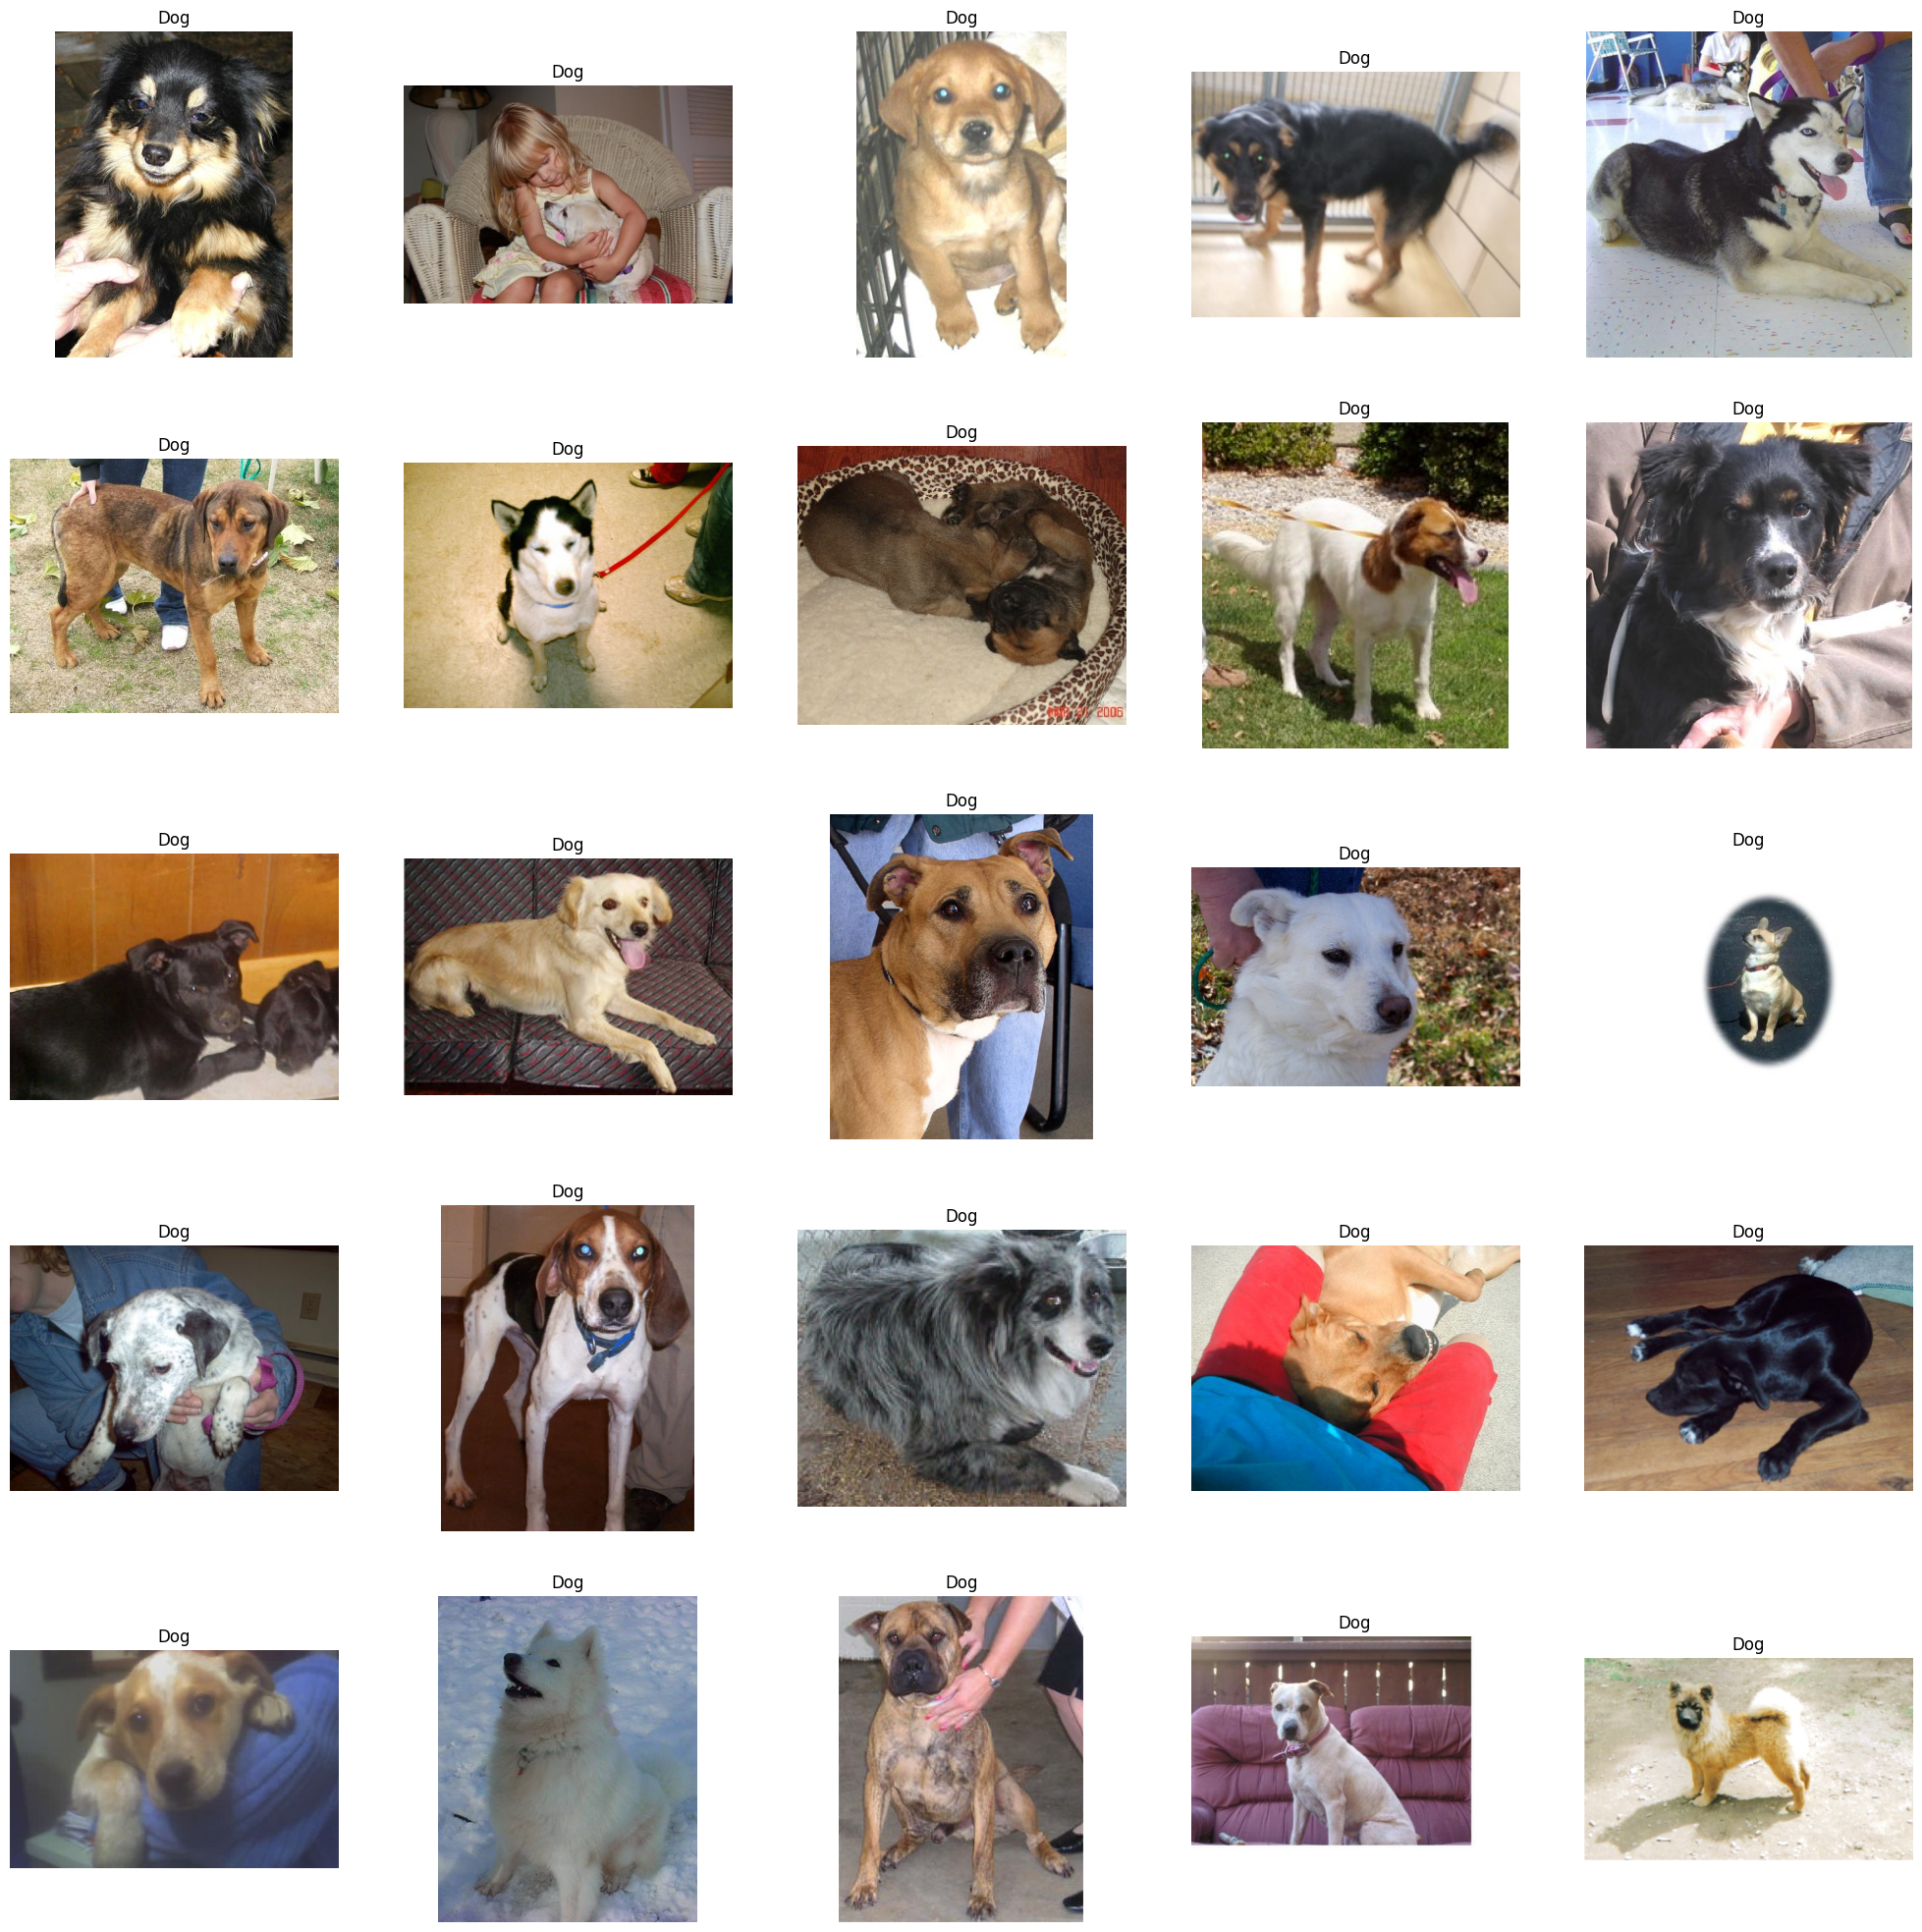

In [10]:
# display grid of images
plt.figure(figsize=(25,25))
temp = df[df['label']==1]['images']
start = random.randint(0, len(temp))
files = temp[start:start+25]

for index, file in enumerate(files):
  plt.subplot(5, 5, index+1)
  img = load_img(file)
  img = np.array(img)
  plt.imshow(img)
  plt.title('Dog')
  plt.axis('off')

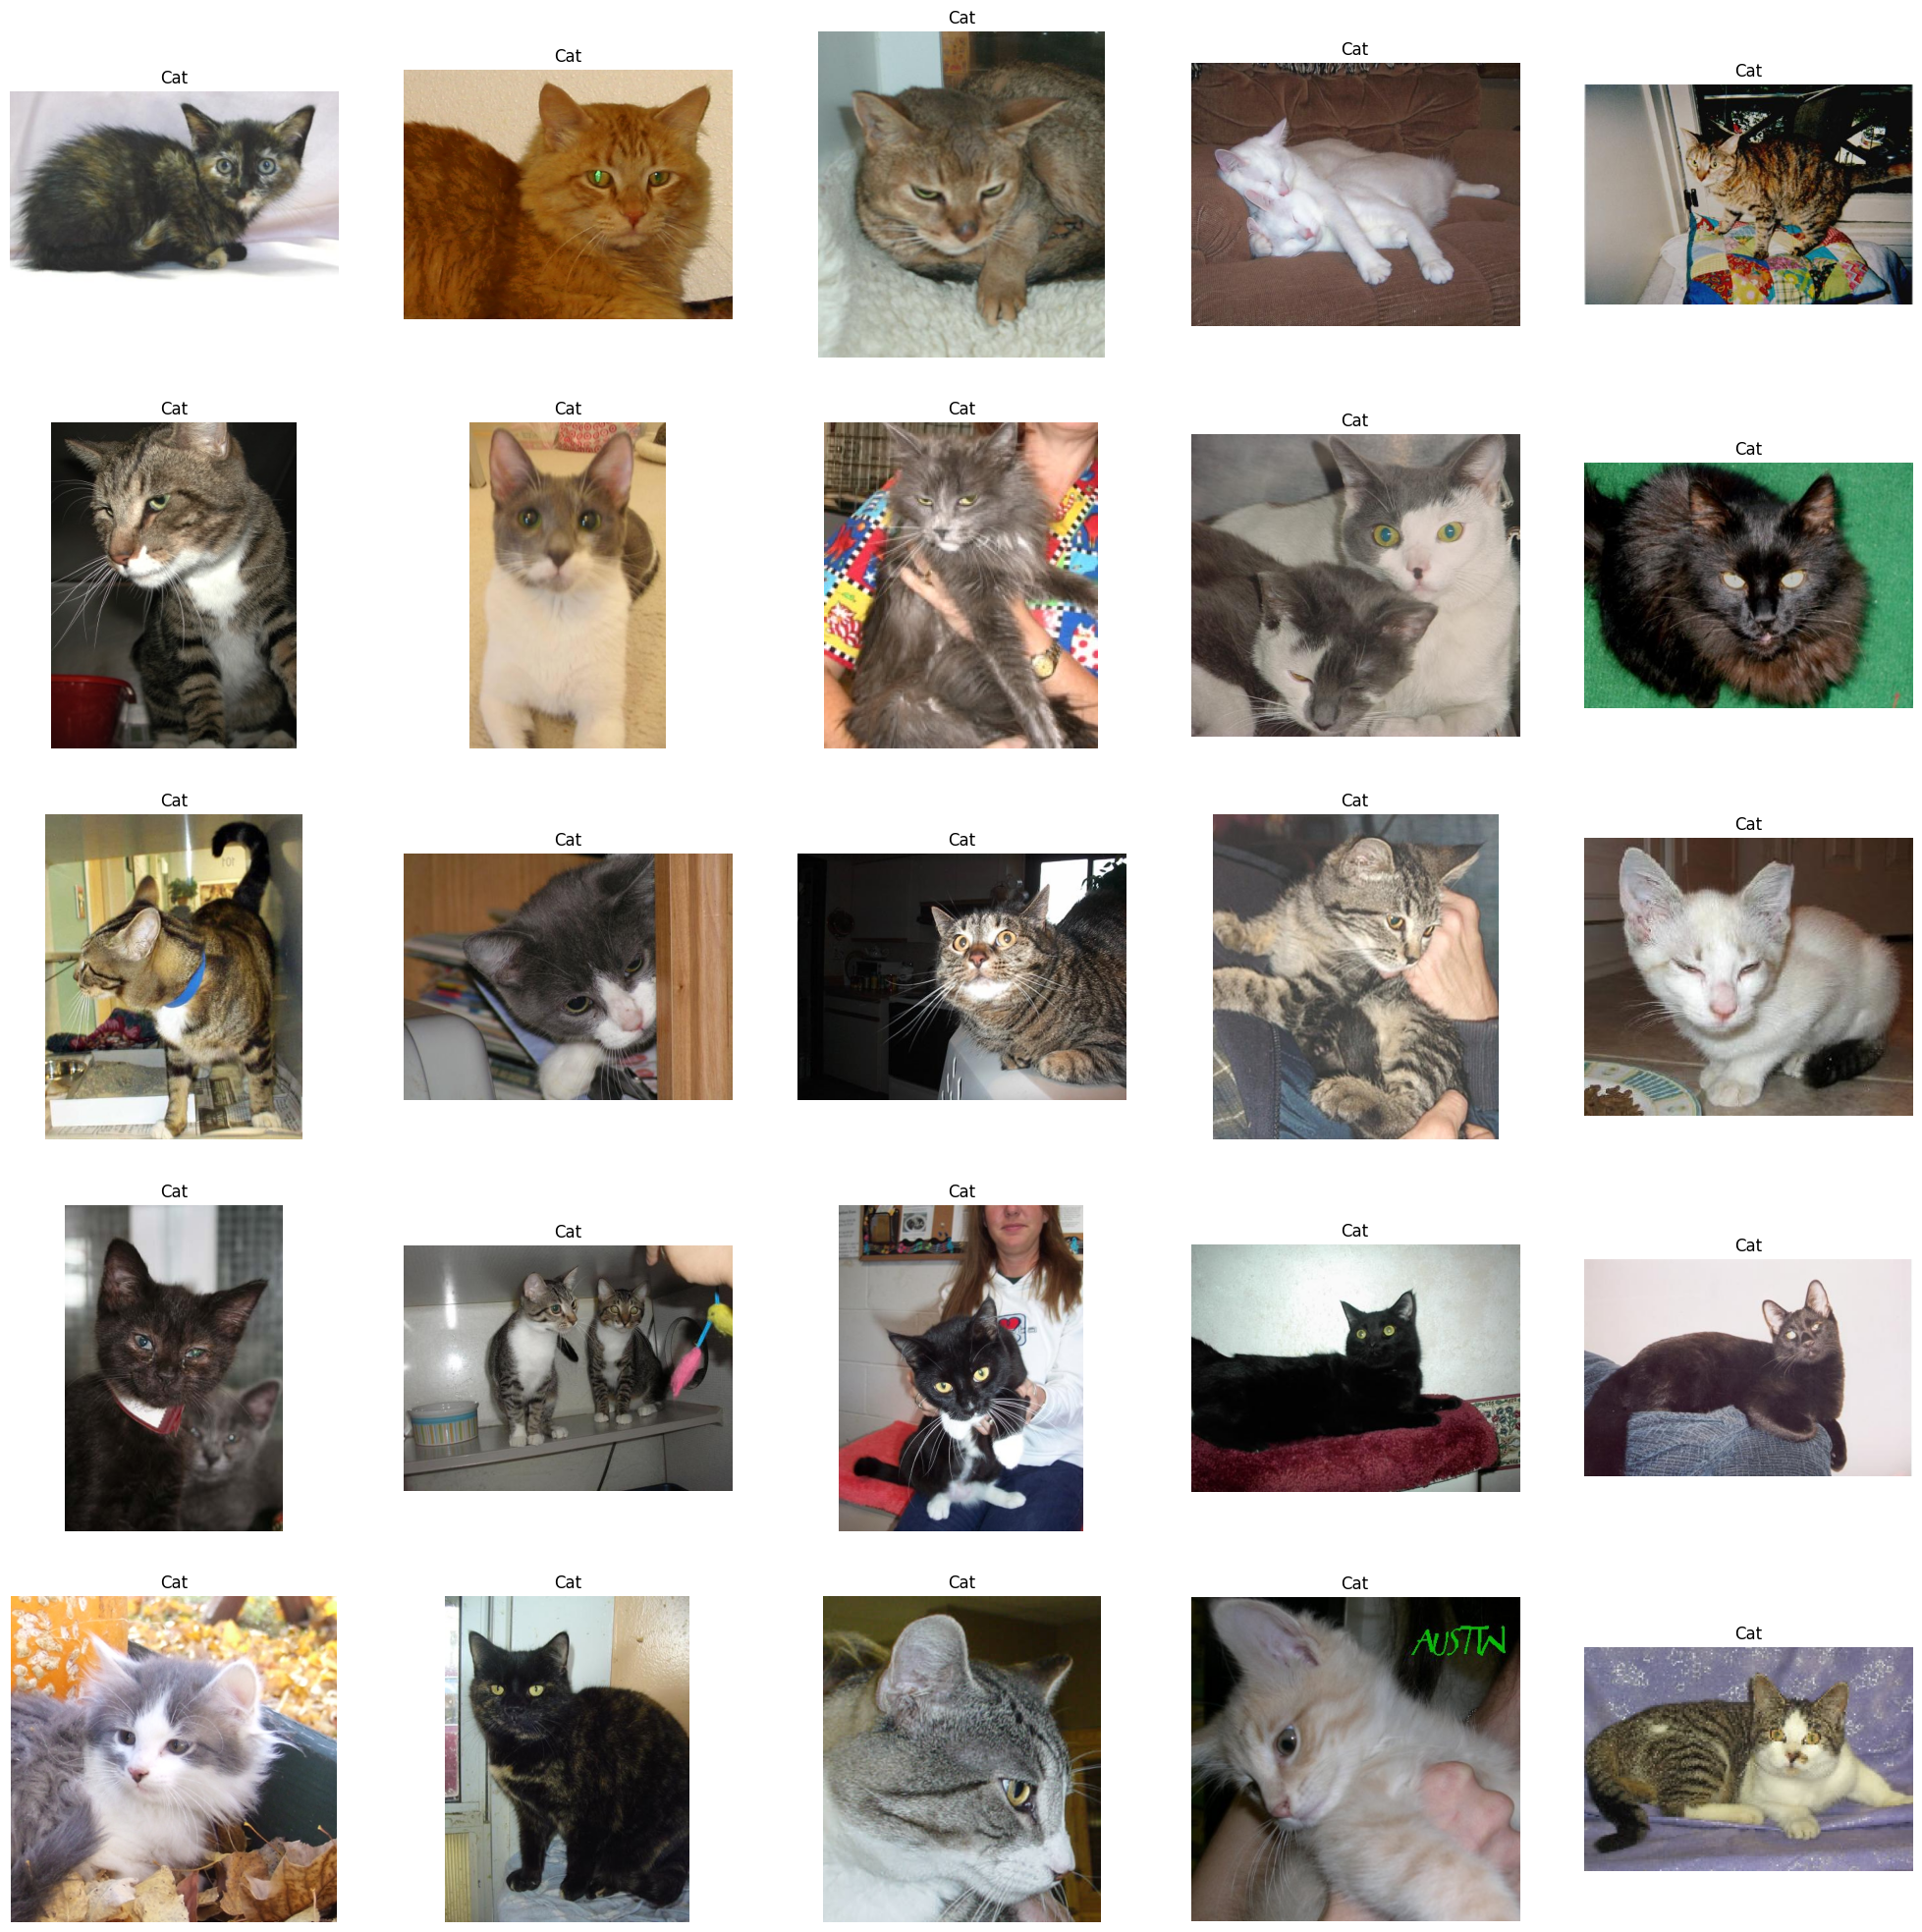

In [11]:
# display grid of images
plt.figure(figsize=(25,25))
temp = df[df['label']==0]['images']
start = random.randint(0, len(temp))
files = temp[start:start+25]

for index, file in enumerate(files):
  plt.subplot(5, 5, index+1)
  img = load_img(file)
  img = np.array(img)
  plt.imshow(img)
  plt.title('Cat')
  plt.axis('off')

In [12]:
print(df['label'].value_counts())

label
1    12499
0    12499
Name: count, dtype: int64


## Create DataGenerator for the Images

In [13]:
df['label'] = df['label'].astype('str')

In [14]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2, random_state=42)

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_generator = ImageDataGenerator(
    rescale=1./255, # normalization of images
    rotation_range=40, # augmentation of images to avoid overfitting
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_generator = ImageDataGenerator(
    rescale=1./255
)

train_iterator = train_generator.flow_from_dataframe(
    dataframe=train,
    x_col='images',
    y_col='label',
    target_size=(128, 128),
    batch_size=512,
    class_mode='binary'
)

val_iterator = val_generator.flow_from_dataframe(
    dataframe=test,
    x_col='images',
    y_col='label',
    target_size=(128, 128),
    batch_size=512,
    class_mode='binary'
)

Found 19998 validated image filenames belonging to 2 classes.
Found 5000 validated image filenames belonging to 2 classes.


## Model Creation

In [16]:
from keras import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense

model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPool2D((2, 2)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPool2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPool2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [17]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,447,137 (24.59 MB)

 Trainable params: 6,447,137 (24.59 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(train_iterator, epochs=10, validation_data=val_iterator)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.5003 - loss: 0.8598 - val_accuracy: 0.6326 - val_loss: 0.6547
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.6207 - loss: 0.6519 - val_accuracy: 0.6970 - val_loss: 0.5806
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 117s 3s/step - accuracy: 0.6840 - loss: 0.5981 - val_accuracy: 0.6694 - val_loss: 0.5993
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 118s 3s/step - accuracy: 0.6916 - loss: 0.5803 - val_accuracy: 0.7198 - val_loss: 0.5474
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.7093 - loss: 0.5670 - val_accuracy: 0.7250 - val_loss: 0.5357
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 114s 3s/step - accuracy: 0.7244 - loss: 0.5435 - val_accuracy: 0.7438 - val_loss: 0.5146
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.7357 - loss: 0.5279 - val_accuracy: 0.7542 - val_loss: 0.4933
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.7471 - loss: 0.5097 - val_accuracy: 0.7492 - v

## Visualization of results

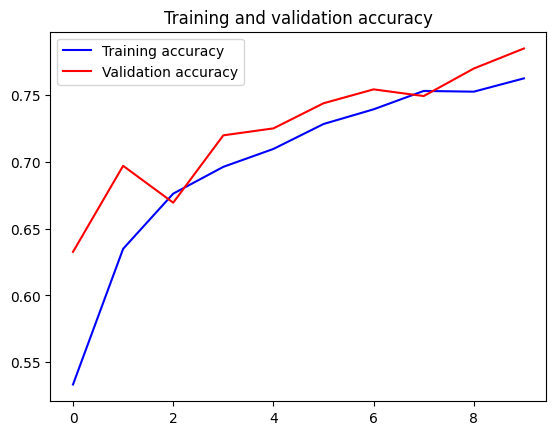

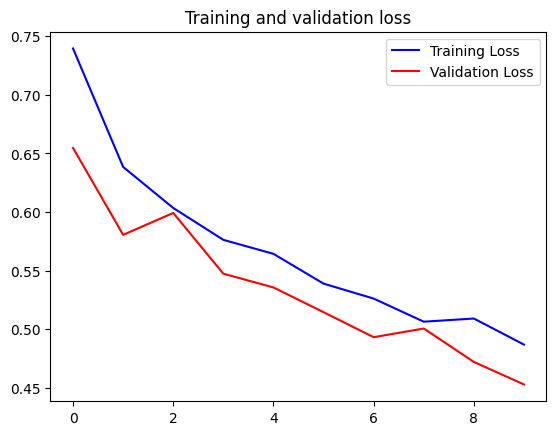

In [19]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training accuracy') # blue
plt.plot(epochs, val_acc, 'r', label='Validation accuracy') # red
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()

loss = history.history['loss']
val_loss = history.history['val_loss']
plt.plot(epochs, loss, 'b', label='Training Loss') # blue
plt.plot(epochs, val_loss, 'r', label='Validation Loss') # red
plt.title('Training and validation loss')
plt.legend()

plt.show()


## Test on real image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Cat


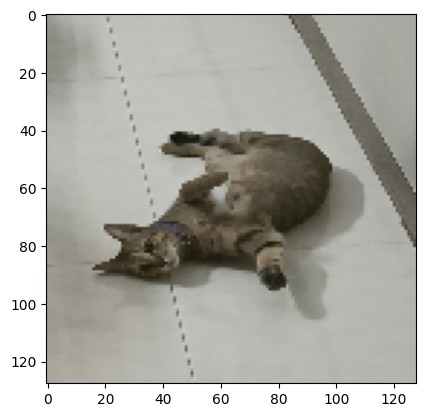

In [22]:
image_path = "test.jpg"
img = load_img(image_path, target_size=(128, 128))
img = np.array(img)
plt.imshow(img)
img = img.reshape(1, 128, 128, 3) # Reshape image to match model input shape (batch_size, height, width, channels)
pred = model.predict(img)
if pred > 0.5:
  print("Dog")
else:
  print("Cat")